In [1]:
!python -m pip install pillow numpy matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageFilter

In [3]:
PROJECT_ROOT = Path("/Users/apple/Desktop/UCL/skills/python3")
API_OUTPUTS_DIR = PROJECT_ROOT / "data" / "api_outputs"
MAPS_DIR = PROJECT_ROOT / "outputs" / "maps"

MAPS_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
cluster_prompts_df = pd.read_csv(API_OUTPUTS_DIR / "cluster_prompts.csv")

selected_clusters = cluster_prompts_df[
    cluster_prompts_df["cluster_name"].isin([
        "dry_exposed",
        "flowing_unstable",
        "rocky_vertical"
    ])
].copy()

selected_clusters

,cluster_id,cluster_name,image_prompt,td_texture_prompt,blender_fragment_prompt
0,0,dry_exposed,"abstract grayscale terrain showing rugged, por...",high contrast erosion pattern with layered gra...,dense cluster of varied height fragments with ...
3,3,flowing_unstable,"abstract monochrome terrain of a deep, narrow ...",high contrast procedural erosion texture simul...,fragmented vertical rock forms with high heigh...
4,4,rocky_vertical,Abstract terrain of rugged vertical rock faces...,Generate a high contrast procedural texture of...,Create fragmented vertical rock formations wit...


In [5]:
def normalize_array(arr):
    arr = arr - arr.min()
    if arr.max() > 0:
        arr = arr / arr.max()
    return arr

In [6]:
def generate_base_noise(size=1024, seed=42):
    rng = np.random.default_rng(seed)
    arr = rng.random((size, size))
    return normalize_array(arr)

In [7]:
def make_dry_exposed_map(size=1024, seed=0):
    rng = np.random.default_rng(seed)
    base = rng.random((size, size))

    # 横纵方向轻微拉伸，让它更像风蚀地表
    stretched = np.zeros_like(base)
    for i in range(size):
        stretched[i] = np.roll(base[i], i // 20)

    arr = 0.7 * base + 0.3 * stretched
    arr = normalize_array(arr)

    # 提高对比，增强裂痕感
    arr = np.clip((arr - 0.4) * 2.0, 0, 1)
    return normalize_array(arr)

In [8]:
def make_flowing_unstable_map(size=1024, seed=1):
    rng = np.random.default_rng(seed)
    base = rng.random((size, size))

    flow = np.zeros_like(base)
    for i in range(size):
        shift = int(20 * np.sin(i / 30))
        flow[i] = np.roll(base[i], shift)

    arr = 0.4 * base + 0.6 * flow
    arr = normalize_array(arr)

    # 更柔和、更连续
    arr = arr ** 1.8
    return normalize_array(arr)

In [9]:
def make_rocky_vertical_map(size=1024, seed=2):
    rng = np.random.default_rng(seed)
    base = rng.random((size, size))

    vertical = np.zeros_like(base)
    for j in range(size):
        vertical[:, j] = np.roll(base[:, j], j // 15)

    arr = 0.5 * base + 0.5 * vertical
    arr = normalize_array(arr)

    # 强化竖向断裂和高差
    arr = np.clip((arr - 0.35) * 2.5, 0, 1)
    return normalize_array(arr)

In [10]:
dry_map = make_dry_exposed_map()
flow_map = make_flowing_unstable_map()
rock_map = make_rocky_vertical_map()

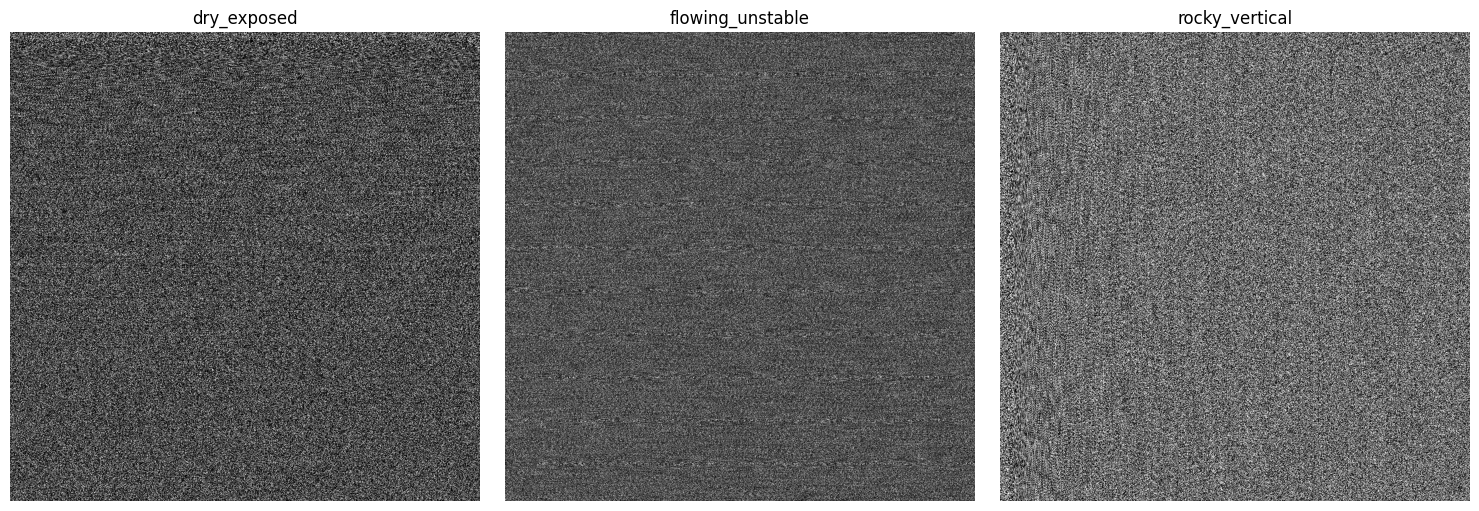

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(dry_map, cmap="gray")
axes[0].set_title("dry_exposed")
axes[0].axis("off")

axes[1].imshow(flow_map, cmap="gray")
axes[1].set_title("flowing_unstable")
axes[1].axis("off")

axes[2].imshow(rock_map, cmap="gray")
axes[2].set_title("rocky_vertical")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [12]:
def save_map(arr, filename):
    img = Image.fromarray((arr * 255).astype(np.uint8))
    img.save(MAPS_DIR / filename)
    print("Saved:", MAPS_DIR / filename)

In [13]:
save_map(dry_map, "cluster0_dry_exposed_height.png")
save_map(flow_map, "cluster3_flowing_unstable_height.png")
save_map(rock_map, "cluster4_rocky_vertical_height.png")

Saved: /Users/apple/Desktop/UCL/skills/python3/outputs/maps/cluster0_dry_exposed_height.png
Saved: /Users/apple/Desktop/UCL/skills/python3/outputs/maps/cluster3_flowing_unstable_height.png
Saved: /Users/apple/Desktop/UCL/skills/python3/outputs/maps/cluster4_rocky_vertical_height.png


In [14]:
def make_mask(arr, threshold=0.55):
    mask = (arr > threshold).astype(float)
    return mask

In [15]:
dry_mask = make_mask(dry_map, 0.55)
flow_mask = make_mask(flow_map, 0.5)
rock_mask = make_mask(rock_map, 0.6)

save_map(dry_mask, "cluster0_dry_exposed_mask.png")
save_map(flow_mask, "cluster3_flowing_unstable_mask.png")
save_map(rock_mask, "cluster4_rocky_vertical_mask.png")

Saved: /Users/apple/Desktop/UCL/skills/python3/outputs/maps/cluster0_dry_exposed_mask.png
Saved: /Users/apple/Desktop/UCL/skills/python3/outputs/maps/cluster3_flowing_unstable_mask.png
Saved: /Users/apple/Desktop/UCL/skills/python3/outputs/maps/cluster4_rocky_vertical_mask.png


In [16]:
def save_texture_variant(arr, filename):
    img = Image.fromarray((arr * 255).astype(np.uint8))
    img = img.filter(ImageFilter.GaussianBlur(radius=2))
    img.save(MAPS_DIR / filename)
    print("Saved:", MAPS_DIR / filename)

In [17]:
save_texture_variant(dry_map, "cluster0_dry_exposed_texture.png")
save_texture_variant(flow_map, "cluster3_flowing_unstable_texture.png")
save_texture_variant(rock_map, "cluster4_rocky_vertical_texture.png")

Saved: /Users/apple/Desktop/UCL/skills/python3/outputs/maps/cluster0_dry_exposed_texture.png
Saved: /Users/apple/Desktop/UCL/skills/python3/outputs/maps/cluster3_flowing_unstable_texture.png
Saved: /Users/apple/Desktop/UCL/skills/python3/outputs/maps/cluster4_rocky_vertical_texture.png
